In [4]:
using IonSim
using QuantumOptics
using PyPlot

In [8]:
function plot_wigner(final_state)
    rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
end


plot_wigner (generic function with 1 method)

In [5]:
function SDF_apply_with_alpha(angle = 0, time = 50.0, cat_state = false, initial_state = nothing)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        println("Preparing cat state superposition...")
        red_angle = -angle
        blue_angle = angle
    end
    trap_freq = 19e5 # 1 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

   k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e6 # Adjust this to push the ion faster/slower
    B_field = 1e-13
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    println(mode)

    ψ_ion = normalize(ion["g"] -  ion["e"])

    
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        println("Using provided initial state...")
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    tspan = 0:0.5:time 
    println("Simulating bichromatic displacement...")
    tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

    final_state = sol[end]

    # ---------------------------------------------------------
# 1. Fundamental Physics Constants
# ---------------------------------------------------------
 hbar = 1.0545718e-34       # Reduced Planck constant (J*s)
 amu = 1.66053906e-27       # Atomic mass unit (kg)
 m_Ca40 = 39.96259 * amu    # Mass of Calcium-40 ion (kg)
 c = 2.99792458e8           # Speed of light (m/s)

# ---------------------------------------------------------
# 2. Your Simulated Experiment Parameters
# ---------------------------------------------------------     
wavelength = transition_λ             # Quadrupole transition wavelength (m)
tspan_end = time * 1e-6              # Total laser interaction time (s)
# ---------------------------------------------------------
# 3. Step-by-Step Calculation
# ---------------------------------------------------------

println("--- VERIFYING DISPLACEMENT PARAMETERS ---")

# Step A: Zero-Point Fluctuation (z_zpf)
# z_zpf = sqrt( ħ / (2 * m * ω_trap) )
omega_trap = 2 * π * trap_freq
z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
println("Zero-Point Fluctuation (z_zpf) : ", round(z_zpf * 1e9, digits=4), " nm")

# Step B: Wavevector Z-Projection (k_z)
# Your vector: k_vec = (x̂ + ẑ) / √2 
# Therefore, projection onto Z is 1/√2
k_total = 2 * π / wavelength
k_z = k_total / sqrt(2)
println("Z-Projected Wavevector (k_z)   : ", round(k_z, digits=2), " m⁻¹")

# Step C: Lamb-Dicke Parameter (η)
# η = k_z * z_zpf
eta = k_z * z_zpf
println("Lamb-Dicke Parameter (η)       : ", round(eta, digits=4))

# Step D: Effective Rabi Frequency (Ω_eff)
# The geometric coupling factor for a Δm=0 quadrupole transition using your 
# specific k_vec and ϵ_vec vectors results in a scaling reduction of 1/4.
# geometric_factor = 1.0 / 4.0
geometric_factor = 1.0 / ( sqrt(3)) 

# STRETCHED STATE: The CG coefficient is exactly 1.0! 
cg_factor = 1.0 # The Clebsch-Gordan factor for Δm=0 in Ca40

# The true effective Rabi frequency acting on the ion's orbitals
Omega_eff = laser_intensity * geometric_factor * cg_factor
println("Effective Rabi Freq (Ω_eff)    : ", Omega_eff, " rad/s")

# Step E: Displacement Magnitude (|α|)
# |α| = 1/2 * η * Ω_eff * t 
alpha_mag = 0.5 * eta * Omega_eff * tspan_end 

println("-----------------------------------------")
println("FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : ", round(alpha_mag, digits=3))
println("-----------------------------------------")
return final_state
end


SDF_apply_with_alpha (generic function with 5 methods)

VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
Simulating bichromatic displacement...
--- VERIFYING DISPLACEMENT PARAMETERS ---
Zero-Point Fluctuation (z_zpf) : 8.1584 nm
Z-Projected Wavevector (k_z)   : 6.09326094e6 m⁻¹
Lamb-Dicke Parameter (η)       : 0.0497
Effective Rabi Freq (Ω_eff)    : 577350.2691896259 rad/s
-----------------------------------------
FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : 0.718
-----------------------------------------
Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
   0.5477213734090359 - 0.00023487500897333im
  -0.5476007566119574 + 0.00023485529864395im
  0.00016780822031409 + 0.39163878669608054im
  -0.0001678462875938 - 0.39163884881932054im
 -0.19772909785026843 + 8.469671539906e-5im
  0.19785594232118597 - 8.47091739709e-5im
   -3.490070021561e-5 - 0.0814617953903451im
     3.48303344135e-5 + 0.08146158848660194im
  0.02899792282099058 - 1.241159389896e-5im
 -0.02904140963773813 + 1.241755491722e-5im
     3.96490666221e-

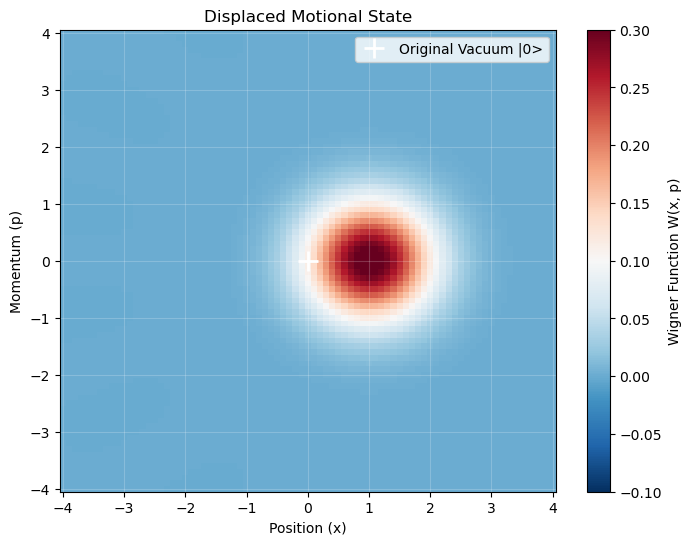

In [13]:
final_state = SDF_apply_with_alpha(0, 50.0, false)

println(final_state)
plot_wigner(final_state)



In [24]:
trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e6 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)
    mode = zmodes(trap)[1]
    println(mode)
    ψ_ion = normalize(ion["g"] - ion["e"])
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

VibrationalMode(ν=1.9e6, axis=ẑ, N=10)


Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
  0.7071067811865475 + 0.0im
 -0.7071067811865475 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                     ⋮
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im
                 0.0 + 0.0im
                -0.0 + 0.0im

In [27]:
function SDF_apply_with_alpha(angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        println("Preparing cat state superposition...")
        red_angle = -angle
        blue_angle = angle
    end
    
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e4 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)

    # ---------------------------------------------------------
    # NEW: DYNAMIC TIME CALCULATION VIA WIGNER-ECKART ENGINE
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    c = 2.99792458e8           

    # 1. Calculate Lamb-Dicke Parameter (η) dynamically
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    # 2. Hijack IonSim's internal matrix element calculator
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    # Feed the dummy laser into the exact internal physics engine
    # (Note: Unexported internal functions need the module prefix 'IonSim.')
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    # 3. Solve the displacemen formula backward to find exactly how long to leave the lasers on
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    # ---------------------------------------------------------

    # Now build the actual lasers and final chamber
    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    println(mode)

    ψ_ion = normalize(ion["g"] - ion["e"])
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        println("Using provided initial state...")
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    
    # Ensure our solver array steps exactly up to our calculated target time
    tspan_array = collect(0:0.5:target_time_us)
    if tspan_array[end] < target_time_us
        push!(tspan_array, target_time_us)
    end

    println("\n--- DYNAMIC DISPLACEMENT SETUP ---")
    println("Target Magnitude (|α|) : ", target_alpha)
    println("Fixed Laser Intensity  : ", laser_intensity, " W/m²")
    println("True Engine Ω_eff      : ", round(Omega_eff, digits=2), " rad/s")
    println("Calculated Time (t)    : ", round(target_time_us, digits=3), " μs")
    println("----------------------------------\n")

    println("Simulating bichromatic displacement...")
    tout, sol = timeevolution.schroedinger_dynamic(tspan_array, ψ_initial, h)

    final_state = sol[end]

    # ---------------------------------------------------------
    # VERIFICATION PRINT BLOCK
    # ---------------------------------------------------------
    println("\n--- VERIFYING DISPLACEMENT PARAMETERS ---")
    println("Zero-Point Fluctuation (z_zpf) : ", round(z_zpf * 1e9, digits=4), " nm")
    println("Z-Projected Wavevector (k_z)   : ", round(k_z, digits=2), " m⁻¹")
    println("Lamb-Dicke Parameter (η)       : ", round(eta, digits=4))
    
    # We no longer calculate geometric_factor manually. We pull Ω_eff directly from the engine!
    println("Effective Rabi Freq (Ω_eff)    : ", Omega_eff, " rad/s")

    # |α| = 1/2 * η * Ω_eff * t 
    alpha_mag = 0.5 * eta * Omega_eff * target_time_s 

    println("-----------------------------------------")
    println("FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : ", round(alpha_mag, digits=3), " (Targeted: $target_alpha)")
    println("-----------------------------------------")
    
    return final_state
end

SDF_apply_with_alpha (generic function with 5 methods)

VibrationalMode(ν=1.9e6, axis=ẑ, N=10)

--- DYNAMIC DISPLACEMENT SETUP ---
Target Magnitude (|α|) : 0.716
Fixed Laser Intensity  : 10000.0 W/m²
True Engine Ω_eff      : 57655.0 rad/s
Calculated Time (t)    : 499.633 μs
----------------------------------

Simulating bichromatic displacement...

--- VERIFYING DISPLACEMENT PARAMETERS ---
Zero-Point Fluctuation (z_zpf) : 8.1584 nm
Z-Projected Wavevector (k_z)   : 6.09326094e6 m⁻¹
Lamb-Dicke Parameter (η)       : 0.0497
Effective Rabi Freq (Ω_eff)    : 57654.99800388868 rad/s
-----------------------------------------
FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : 0.716 (Targeted: 0.716)
-----------------------------------------
Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
   0.5450724734244152 + 1.404863281754e-5im
  -0.5500630133083152 - 1.366575032934e-5im
   -5.423294328424e-5 + 0.38992256197509145im
    5.364898271983e-5 - 0.39348372055944586im
 -0.19699261794464973 - 5.015637022388e-5im
  0.1987881

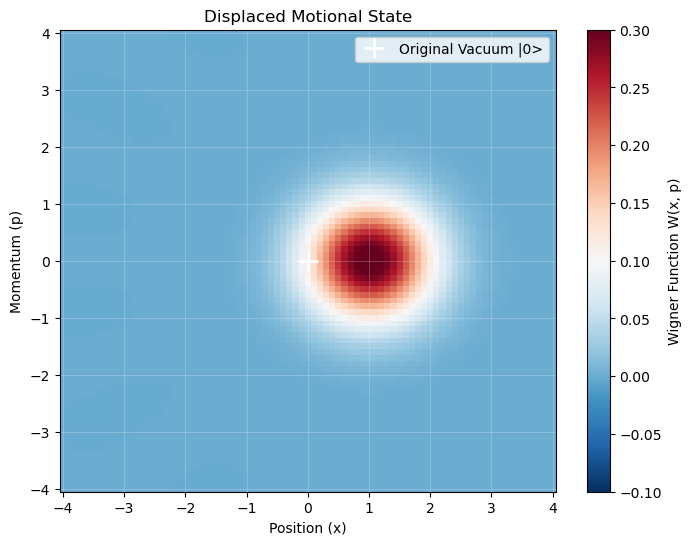

In [28]:
final_state = SDF_apply_with_alpha()

println(final_state)
plot_wigner(final_state)



In [26]:
# 1. Grab the exact mode object used in the simulation (no generic FockBasis!)
sim_mode = zmodes(trap)[1]
a = 0.716 * im 

# 2. Build the displacement operator using the IonSim mode
# IonSim has a built-in displace() method specifically for VibrationalModes
D_motion = IonSim.displace(sim_mode, a)

# 3. Create a "Do Nothing" operator for the ion's spin
I_spin = identityoperator(ion["g"].basis)

 ψ_ion = normalize(ion["g"] -  ion["e"])

# 4. Combine them into a full system operator (Spin ⊗ Motion)
D_system = identityoperator(ψ_ion.basis) ⊗ D_motion

# 5. Apply the operator to the state (The bases now match perfectly!)
displaced_final_state = D_system * ψ_initial

println(displaced_final_state)

Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
     0.54722151763696 + 0.0im
    -0.54722151763696 + 0.0im
                  0.0 + 0.39181060662806294im
                  0.0 - 0.39181060662806294im
 -0.19836918681147203 + 0.0im
  0.19836918681147203 + 0.0im
                  0.0 - 0.08200240843749869im
                  0.0 + 0.08200240843749869im
  0.02935686222252916 + 0.0im
 -0.02935686222252916 + 0.0im
                  0.0 + 0.0094002121203422im
                  0.0 - 0.0094002121203422im
 -0.00274773650091092 + 0.0im
  0.00274773650091092 + 0.0im
                  0.0 - 0.00074359780052438im
                  0.0 + 0.00074359780052438im
  0.00018824989148011 + 0.0im
 -0.00018824989148011 + 0.0im
                  0.0 + 4.484896272068e-5im
                  0.0 - 4.484896272068e-5im
   -1.061027626674e-5 + 0.0im
    1.061027626674e-5 + 0.0im
